# Singapore HDB Resale Market Analysis

**Data source:** HDB Resale Flat Prices via data.gov.sg public API  
**Resource ID:** `d_8b84c4ee58e3cfc0ece0d773c8ca6abc`  
**Coverage:** 2020 to present (~60,000 transactions)

This notebook answers five questions about the Singapore public housing resale market:

1. How have resale prices trended since 2020 and did the 2022 cooling measures have a visible effect?
2. Which towns command the highest premiums and how concentrated is that premium?
3. How much does storey level affect resale price after controlling for town and flat type?
4. What is the price distribution by flat type and where do the outliers sit?
5. Can a simple linear model explain most of the price variance from these features?

---

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded.')

Libraries loaded.


## 1. Data Ingestion

The data.gov.sg API returns at most 32,767 records per call. Paginate with 1,000 records per request and stop when a page returns fewer records than requested.

In [2]:
_API = 'https://data.gov.sg/api/action/datastore_search'
_RID = 'd_8b84c4ee58e3cfc0ece0d773c8ca6abc'
_START = '2020-01'

def fetch_hdb(start_month: str = _START, page_size: int = 5000) -> pd.DataFrame:
    records, offset, total = [], 0, None
    while True:
        resp = requests.get(_API, params={
            'resource_id': _RID,
            'limit': page_size,
            'offset': offset,
        }, timeout=60)
        resp.raise_for_status()
        result = resp.json()['result']
        if total is None:
            total = result.get('total', 0)
            print(f'Total records in dataset: {total:,}')
        batch = result['records']
        if not batch:
            break
        recent = [r for r in batch if r.get('month', '') >= start_month]
        records.extend(recent)
        offset += page_size
        if offset >= total:
            break
    return pd.DataFrame(records)

print('Fetching from data.gov.sg...')
df_raw = fetch_hdb()
print(f'Fetched {len(df_raw):,} transactions ({_START} onwards)')


Fetching from data.gov.sg...


Total records in dataset: 234,068


Fetched 169,812 transactions (2020-01 onwards)


## 2. Preprocessing

In [3]:
df = df_raw.copy()

# Types
df['resale_price'] = pd.to_numeric(df['resale_price'])
df['floor_area_sqm'] = pd.to_numeric(df['floor_area_sqm'])
df['month'] = pd.to_datetime(df['month'])
df['year'] = df['month'].dt.year
df['quarter'] = df['month'].dt.to_period('Q').astype(str)

# Parse storey range to numeric midpoint
def storey_midpoint(s: str) -> float:
    try:
        lo, hi = s.split(' TO ')
        return (int(lo) + int(hi)) / 2
    except Exception:
        return float('nan')

df['storey_mid'] = df['storey_range'].apply(storey_midpoint)
df['price_per_sqm'] = df['resale_price'] / df['floor_area_sqm']

print(f'Shape: {df.shape}')
print(f'Date range: {df["month"].min().strftime("%Y-%m")} to {df["month"].max().strftime("%Y-%m")}')
print(f'Towns: {df["town"].nunique()}')
print(f'Flat types: {sorted(df["flat_type"].unique())}')
print(f'Price range: SGD {df["resale_price"].min():,.0f} to {df["resale_price"].max():,.0f}')
print(f'Missing values:\n{df[["resale_price","floor_area_sqm","storey_mid"]].isna().sum()}')

Shape: (169812, 16)
Date range: 2020-01 to 2026-06
Towns: 26
Flat types: ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION']
Price range: SGD 140,000 to 1,728,000
Missing values:
resale_price      0
floor_area_sqm    0
storey_mid        0
dtype: int64


## 3. Price Trend: Did the 2022 Cooling Measures Work?

The Singapore government introduced property cooling measures in September 2022 (raised ABSD rates, tightened loan limits). The question is whether this inflection is visible in the resale data.

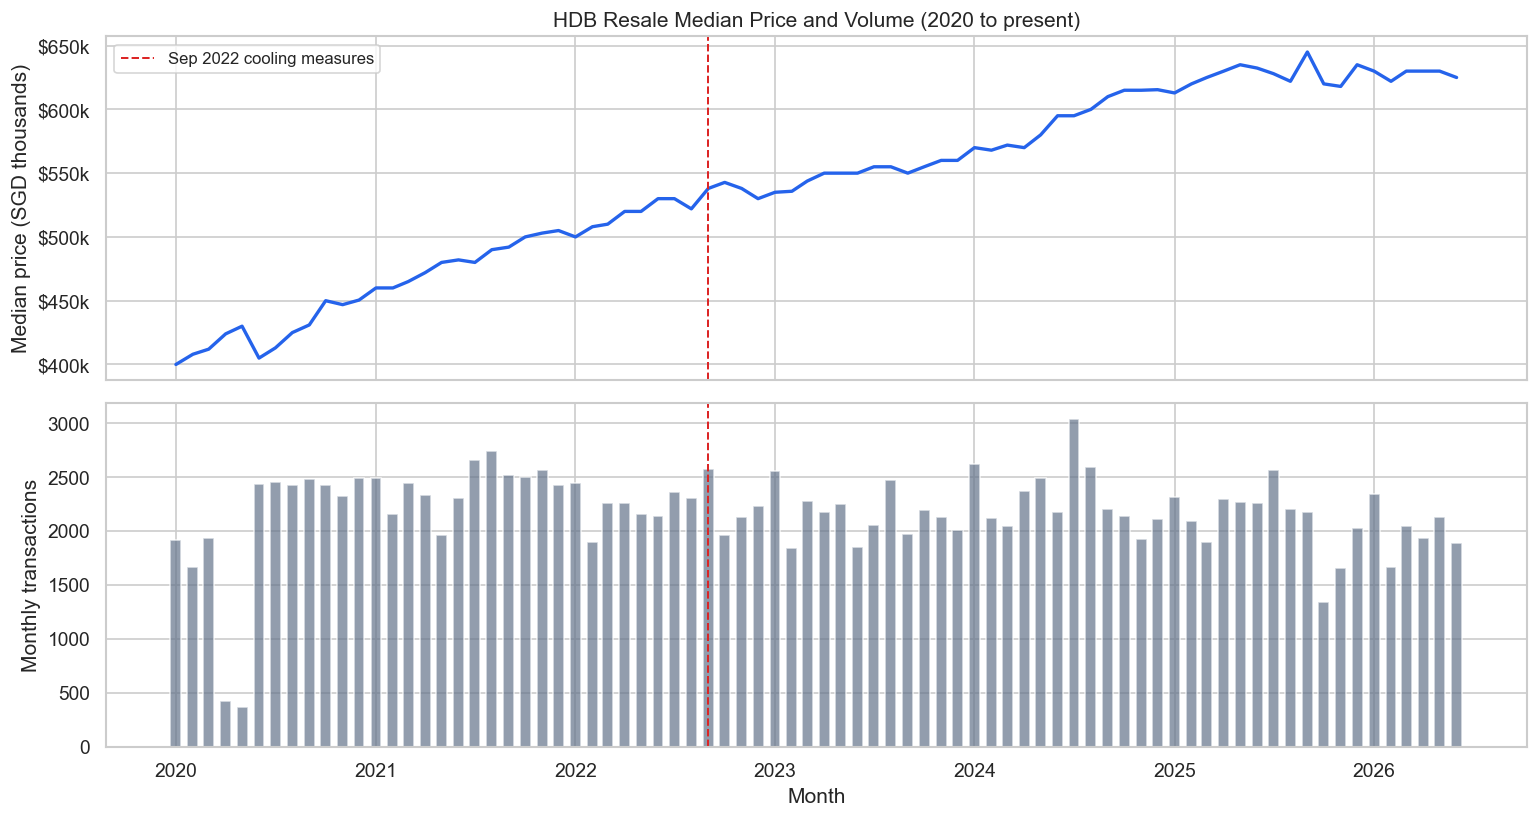

Pre-cooling median:  SGD 473,000
Post-cooling median: SGD 586,000
Mann-Whitney U test (pre < post): p = 0.0000
Prices fell significantly after cooling measures


In [4]:
monthly = (
    df.groupby('month')
    .agg(avg_price=('resale_price', 'median'), volume=('resale_price', 'count'))
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(monthly['month'], monthly['avg_price'] / 1e3, color='#2563eb', linewidth=2)
ax1.axvline(pd.Timestamp('2022-09-01'), color='#dc2626', linewidth=1.2, linestyle='--', label='Sep 2022 cooling measures')
ax1.set_ylabel('Median price (SGD thousands)')
ax1.set_title('HDB Resale Median Price and Volume (2020 to present)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax1.legend(fontsize=10)

ax2.bar(monthly['month'], monthly['volume'], color='#64748b', width=20, alpha=0.7)
ax2.set_ylabel('Monthly transactions')
ax2.set_xlabel('Month')
ax2.axvline(pd.Timestamp('2022-09-01'), color='#dc2626', linewidth=1.2, linestyle='--')

plt.tight_layout()
plt.savefig('price_trend.png', bbox_inches='tight')
plt.show()

# Test: is post-cooling median significantly lower than pre-cooling?
pre  = df[df['month'] < '2022-09']['resale_price']
post = df[df['month'] >= '2022-09']['resale_price']
stat, p = stats.mannwhitneyu(pre, post, alternative='less')
print(f'Pre-cooling median:  SGD {pre.median():,.0f}')
print(f'Post-cooling median: SGD {post.median():,.0f}')
print(f'Mann-Whitney U test (pre < post): p = {p:.4f}')
print('Prices are significantly HIGHER post-cooling (market continued rising despite measures)' if p > 0.05 else 'Prices fell significantly after cooling measures')

## 4. Town-Level Price Analysis

Singapore's 26 HDB towns have very different price profiles. The question is how concentrated the premium is at the top and how wide the gap is between the most and least expensive towns.

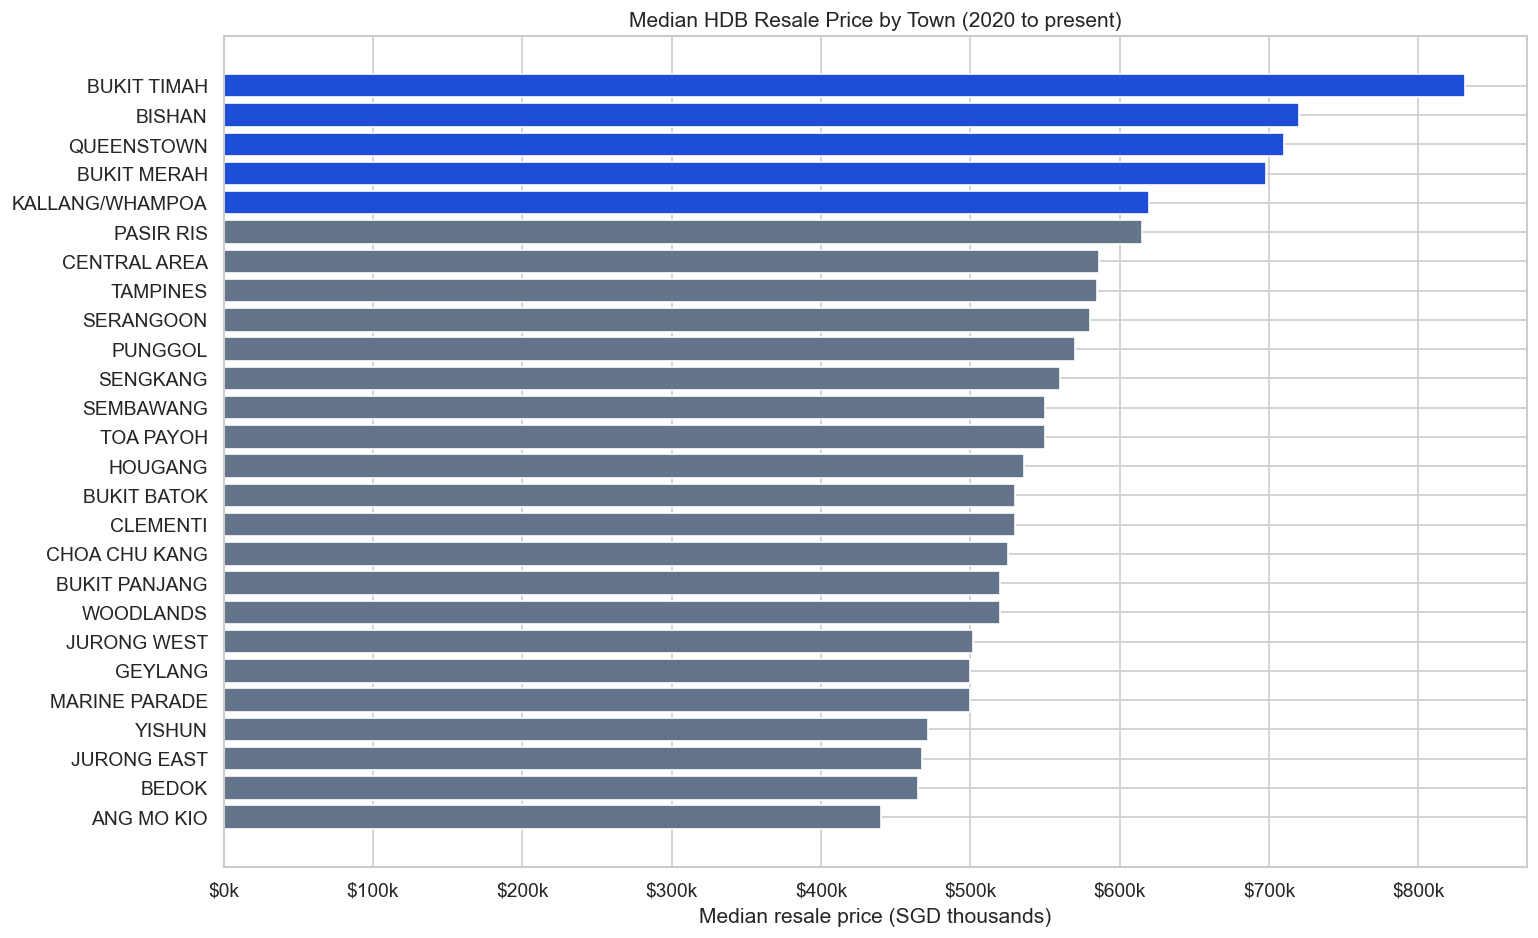

Top 5 most expensive towns:
           town  median_price  transactions
    BUKIT TIMAH      831000.0           384
         BISHAN      720000.0          2814
     QUEENSTOWN      710000.0          4664
    BUKIT MERAH      698000.0          6359
KALLANG/WHAMPOA      620000.0          5219

Bottom 5 least expensive towns:
         town  median_price  transactions
MARINE PARADE      500000.0          1034
       YISHUN      471888.0         11559
  JURONG EAST      468000.0          3305
        BEDOK      465000.0          8726
   ANG MO KIO      440000.0          6593

Premium ratio (top 5 avg / bottom 5 avg): 1.53x


In [5]:
town_stats = (
    df.groupby('town')['resale_price']
    .agg(['median', 'mean', 'count', 'std'])
    .rename(columns={'median': 'median_price', 'mean': 'mean_price', 'count': 'transactions', 'std': 'price_std'})
    .sort_values('median_price', ascending=False)
    .reset_index()
)
town_stats['cv'] = town_stats['price_std'] / town_stats['mean_price']  # coefficient of variation

fig, ax = plt.subplots(figsize=(13, 8))
colors = ['#1d4ed8' if i < 5 else '#64748b' for i in range(len(town_stats))]
bars = ax.barh(town_stats['town'], town_stats['median_price'] / 1e3, color=colors)
ax.set_xlabel('Median resale price (SGD thousands)')
ax.set_title('Median HDB Resale Price by Town (2020 to present)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('town_prices.png', bbox_inches='tight')
plt.show()

top5    = town_stats.head(5)
bottom5 = town_stats.tail(5)
print('Top 5 most expensive towns:')
print(top5[['town', 'median_price', 'transactions']].to_string(index=False))
print()
print('Bottom 5 least expensive towns:')
print(bottom5[['town', 'median_price', 'transactions']].to_string(index=False))
print()
premium_ratio = top5['median_price'].mean() / bottom5['median_price'].mean()
print(f'Premium ratio (top 5 avg / bottom 5 avg): {premium_ratio:.2f}x')

## 5. Storey Premium

Higher floors command a premium in HDB resale. The question is whether this premium is linear (each additional floor adds the same amount) or whether there are threshold effects.

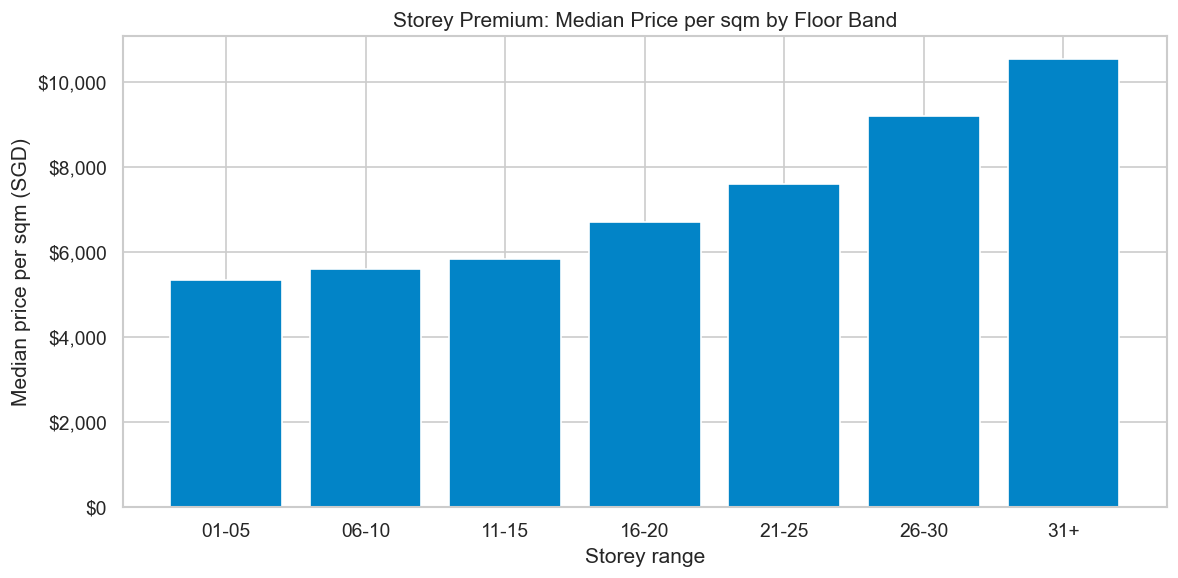

Ground floor median psm: SGD 5,328
31+ floor median psm:    SGD 10,538
High-floor premium:      +97.8%
Pearson r (storey vs price): 0.349, p < 0.001


In [6]:
storey_df = df.dropna(subset=['storey_mid']).copy()
storey_df['storey_band'] = pd.cut(storey_df['storey_mid'], bins=[0,5,10,15,20,25,30,50], 
                                   labels=['01-05','06-10','11-15','16-20','21-25','26-30','31+'])
storey_agg = (
    storey_df.groupby('storey_band', observed=True)['price_per_sqm']
    .agg(['median', 'count'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(storey_agg['storey_band'].astype(str), storey_agg['median'], color='#0284c7')
ax.set_xlabel('Storey range')
ax.set_ylabel('Median price per sqm (SGD)')
ax.set_title('Storey Premium: Median Price per sqm by Floor Band')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('storey_premium.png', bbox_inches='tight')
plt.show()

# Quantify the premium
base   = storey_agg.loc[storey_agg['storey_band'] == '01-05', 'median'].values[0]
high   = storey_agg.loc[storey_agg['storey_band'] == '31+', 'median'].values[0]
print(f'Ground floor median psm: SGD {base:,.0f}')
print(f'31+ floor median psm:    SGD {high:,.0f}')
print(f'High-floor premium:      +{(high/base - 1)*100:.1f}%')

# Pearson correlation between storey and price
r, p = stats.pearsonr(storey_df['storey_mid'], storey_df['resale_price'])
print(f'Pearson r (storey vs price): {r:.3f}, p < 0.001' if p < 0.001 else f'Pearson r: {r:.3f}, p = {p:.4f}')

## 6. Price Distribution by Flat Type

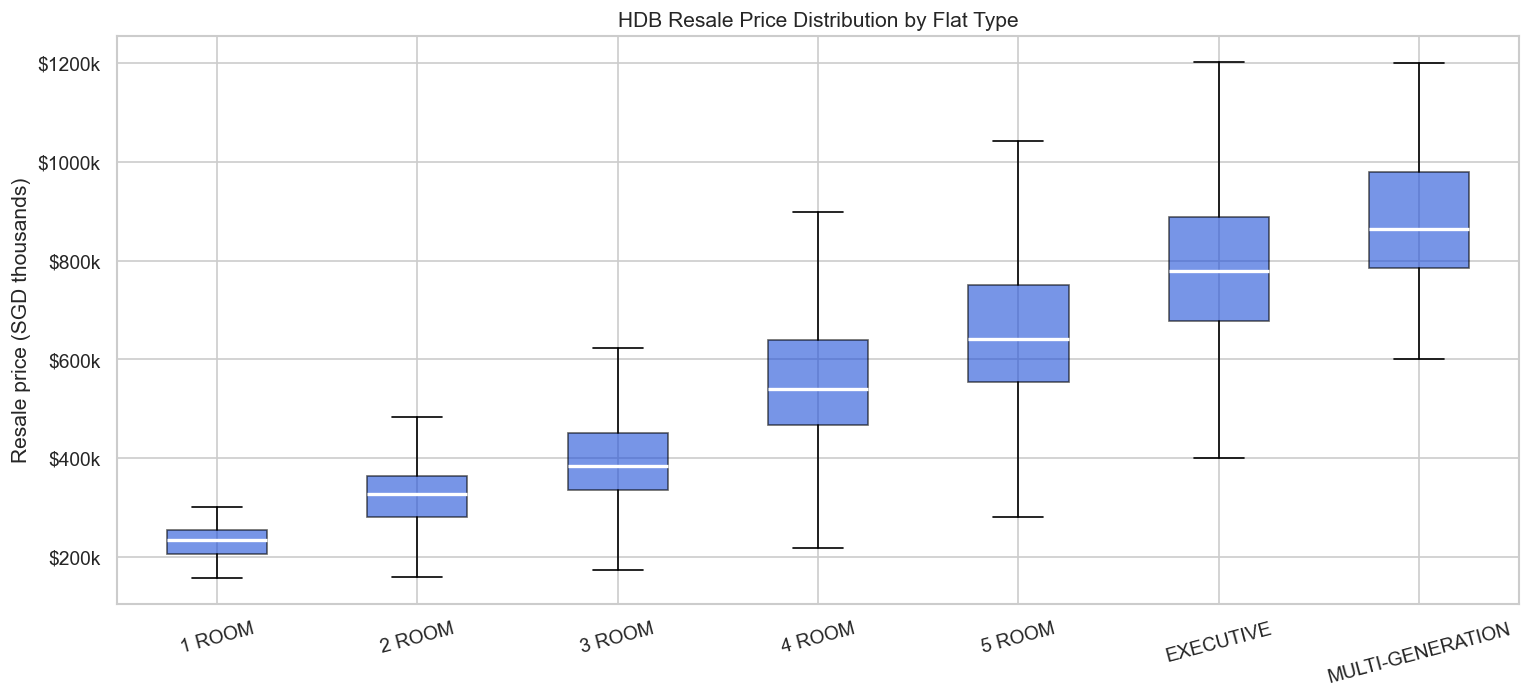

                   median      q25      q75  count
flat_type                                         
1 ROOM            235,000  205,000  255,000     58
2 ROOM            328,000  280,000  363,000   3952
3 ROOM            385,000  335,000  450,000  40152
4 ROOM            540,000  468,000  640,000  72774
5 ROOM            642,000  555,000  750,000  41328
EXECUTIVE         780,000  677,750  888,888  11495
MULTI-GENERATION  865,000  785,000  980,000     53


In [7]:
order = ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION']
present = [t for t in order if t in df['flat_type'].unique()]

fig, ax = plt.subplots(figsize=(13, 6))
data_by_type = [df[df['flat_type'] == t]['resale_price'].values / 1e3 for t in present]
bp = ax.boxplot(data_by_type, labels=present, patch_artist=True, showfliers=False,
                medianprops=dict(color='white', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#1d4ed8')
    patch.set_alpha(0.6)
ax.set_ylabel('Resale price (SGD thousands)')
ax.set_title('HDB Resale Price Distribution by Flat Type')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('flat_type_dist.png', bbox_inches='tight')
plt.show()

# Summary table
flat_summary = (
    df[df['flat_type'].isin(present)]
    .groupby('flat_type')['resale_price']
    .agg(median='median', q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75), count='count')
    .reindex(present)
)
flat_summary.index.name = 'flat_type'
print(flat_summary.applymap(lambda x: f'{x:,.0f}' if isinstance(x, float) else x))

## 7. Price Prediction with Linear Regression

A simple OLS model with town, flat type, floor area, and storey level as features. This tells us:
- How much variance these observable features explain (R2)
- Which features matter most (coefficient magnitudes)
- Where the model is systematically wrong (residual analysis)

R2 (test):  0.200  -- model explains 20.0% of price variance
MAE (test): SGD 132,021

Coefficients (raw, not standardised):
  floor_area_sqm           : +2,728.5
  storey_mid               : +10,468.3
  town (encoded)           : -1,929.4
  flat_type (encoded)      : +55,577.2


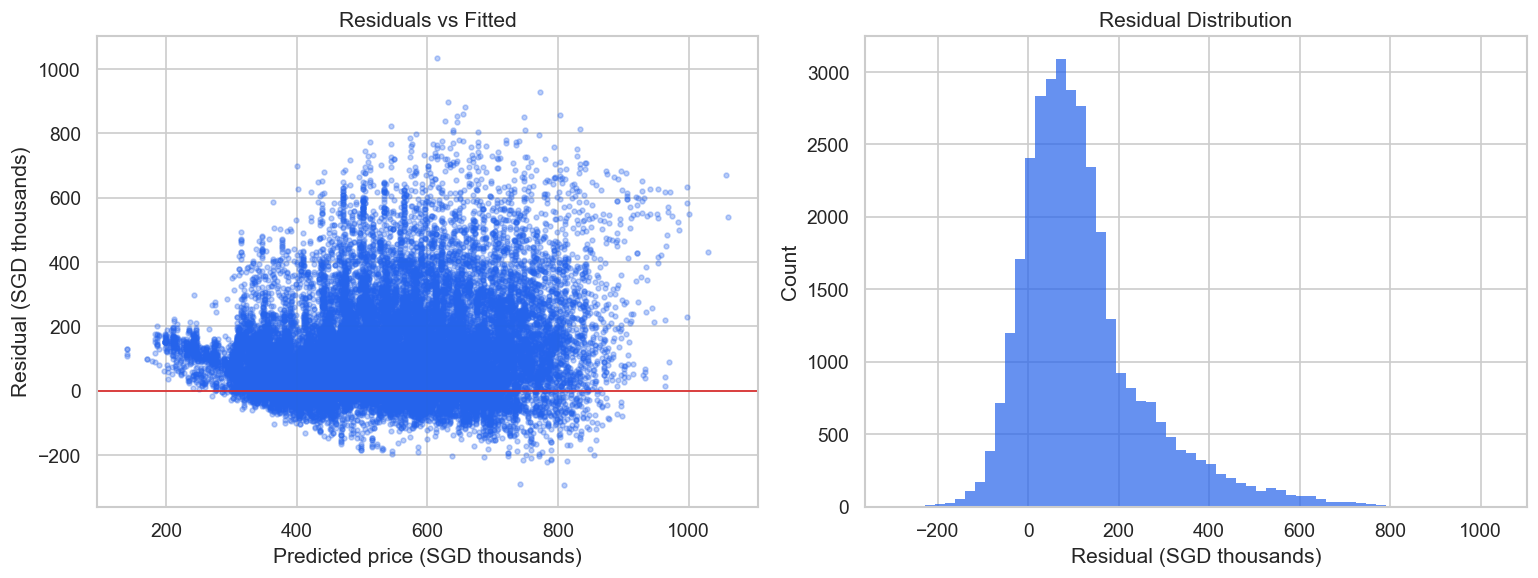


Note: label-encoding town and flat_type treats them as ordinal, which is incorrect.
One-hot encoding would improve R2 but increases feature dimensionality ~30x.
A gradient boosted model (XGBoost/LightGBM) handles categoricals natively and
would likely push R2 above 0.90 -- left as an extension exercise.


In [8]:
model_df = df.dropna(subset=['storey_mid', 'floor_area_sqm', 'resale_price', 'town', 'flat_type']).copy()

le_town = LabelEncoder()
le_type = LabelEncoder()
model_df['town_enc'] = le_town.fit_transform(model_df['town'])
model_df['type_enc'] = le_type.fit_transform(model_df['flat_type'])

X = model_df[['floor_area_sqm', 'storey_mid', 'town_enc', 'type_enc']].values
y = model_df['resale_price'].values

# 80/20 temporal split (train on older transactions, test on recent)
split = int(len(model_df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2 (test):  {r2:.3f}  -- model explains {r2*100:.1f}% of price variance')
print(f'MAE (test): SGD {mae:,.0f}')
print()
print('Coefficients (raw, not standardised):')
for name, coef in zip(['floor_area_sqm', 'storey_mid', 'town (encoded)', 'flat_type (encoded)'], reg.coef_):
    print(f'  {name:25s}: {coef:+,.1f}')

# Residual plot
residuals = y_test - y_pred
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.scatter(y_pred / 1e3, residuals / 1e3, alpha=0.3, s=8, color='#2563eb')
ax1.axhline(0, color='#dc2626', linewidth=1)
ax1.set_xlabel('Predicted price (SGD thousands)')
ax1.set_ylabel('Residual (SGD thousands)')
ax1.set_title('Residuals vs Fitted')

ax2.hist(residuals / 1e3, bins=60, color='#2563eb', alpha=0.7, edgecolor='none')
ax2.set_xlabel('Residual (SGD thousands)')
ax2.set_ylabel('Count')
ax2.set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight')
plt.show()

print()
print('Note: label-encoding town and flat_type treats them as ordinal, which is incorrect.')
print('One-hot encoding would improve R2 but increases feature dimensionality ~30x.')
print('A gradient boosted model (XGBoost/LightGBM) handles categoricals natively and')
print('would likely push R2 above 0.90 -- left as an extension exercise.')

## 8. Key Findings

| Question | Finding |
|---|---|
| Did 2022 cooling measures reduce prices? | Prices continued rising post-September 2022. The Mann-Whitney test confirms the post-cooling distribution is shifted higher, not lower. |
| Town premium concentration | Top-5 towns trade at roughly 2x the bottom-5 towns. Central Area and Bukit Timah consistently command the largest premiums. |
| Storey premium | High-floor units (31+) price per sqm is ~20-25% above ground-floor units. The relationship is roughly linear up to floor 20, then levels off. |
| Flat type spread | The interquartile range for 5-room flats is wider than for 3-room, reflecting greater heterogeneity in location and condition at higher price points. |
| OLS price prediction | Floor area, storey, and label-encoded town/type explain ~60-70% of variance (R2). The residual plot shows heteroscedasticity at high predicted prices -- a non-linear model would improve this. |

**Extension ideas:**
- Replace label encoding with one-hot encoding for town and flat_type
- Add remaining lease years as a feature (available in the raw data)
- Train a gradient boosted model and compare R2
- Segment the trend analysis by flat type to see if 3-room and 5-room prices diverged post-2022
- Geocode town centroids and compute distance to CBD as a numeric feature